# Elliptic PDE

A Julia translation of the [Python elliptic-pde demo](https://github.com/QMCSoftware/QMCSoftware/blob/develop/demos/elliptic-pde.ipynb).

In [1]:
using QMCJu
using LinearAlgebra
using SpecialFunctions: besselk, gamma
using Plots
using Printf
using Random
Random.seed!(9999)

TaskLocalRNG()

We apply Monte Carlo and quasi-Monte Carlo methods to approximate the expected value of a quantity of interest derived from the solution of a one-dimensional elliptic PDE, where the diffusion coefficient is a lognormal Gaussian random field. This is often referred to as *the fruitfly problem* of uncertainty quantification.

> **Note:** The Python version of this demo also includes multilevel MC/QMC methods (`CubMLMC`, `CubMLQMCCont`), which are not yet implemented in QMCJu. This notebook covers Sections 1–2 of the original demo. Multilevel methods will be added in a future release.

## 1. Problem Definition

Let $Q$ be a quantity of interest derived from the solution $u(x, \omega)$ of the 1D elliptic PDE

$$-\frac{d}{dx}\bigg(a(x, \omega) \frac{d}{dx} u(x, \omega) \bigg) = f(x), \quad 0 \leq x \leq 1,$$
$$u(0, \cdot) = u_0, \quad u(1, \cdot) = u_1.$$

The diffusion coefficient $a(x, \omega) = \exp(b(x, \omega))$ is a lognormal Gaussian random field with Matérn covariance

$$c(x, y) = \frac{2^{1-\nu}}{\Gamma(\nu)} \left(\frac{\|x - y\|}{\lambda}\right)^\nu K_\nu\!\left(\frac{\|x - y\|}{\lambda}\right)$$

where $\lambda$ is the length scale, $\nu$ is the smoothness parameter, $\Gamma$ is the gamma function, and $K_\nu$ is the modified Bessel function of the second kind.

We begin by defining the Matérn covariance function:

In [2]:
function matern(x, y; smoothness=1, lengthscale=1)
    r = abs.(x .- y) ./ lengthscale
    prefactor = 2.0^(1 - smoothness) / gamma(smoothness)
    cov = prefactor .* (r .^ smoothness) .* besselk.(smoothness, r)
    # besselk diverges at r=0; covariance at distance 0 is 1
    cov[r .== 0] .= 1.0
    return cov
end

function get_covariance_matrix(pts; smoothness=1, lengthscale=1)
    X = pts' .* ones(length(pts))
    Y = ones(length(pts))' .* pts
    return matern(X, Y; smoothness, lengthscale)
end

get_covariance_matrix (generic function with 1 method)

Let's look at the covariance matrix for `n = 25` equidistant points in [0, 1]:

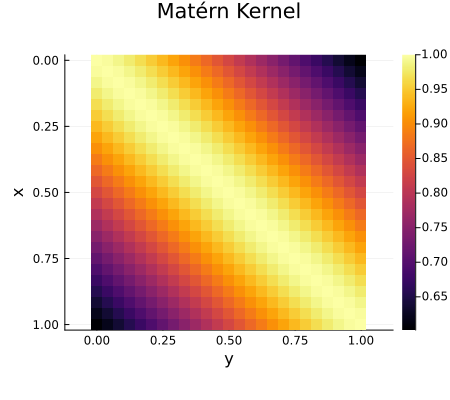

In [3]:
let n = 25, pts = collect(range(0, 1, length=n))
    heatmap(pts, pts, get_covariance_matrix(pts);
        xlabel="y", ylabel="x", title="Matérn Kernel",
        yflip=true, aspect_ratio=:equal, size=(450, 400))
end

### Karhunen–Loève Expansion

A Gaussian random field $b(x, \omega)$ with covariance matrix $C = V W V^T$ can be sampled as

$$\boldsymbol{b} = V W^{1/2} \boldsymbol{x}$$

where $\boldsymbol{x} \sim \mathcal{N}(0, I)$. We compute the eigenvalue decomposition:

In [4]:
function get_eigenpairs(n; smoothness=1, lengthscale=1)
    h = 1 / (n - 1)
    pts = collect(range(h/2, 1 - h/2, length=n - 1))
    cov = get_covariance_matrix(pts; smoothness, lengthscale)
    F = eigen(Symmetric(cov))
    # Sort descending by eigenvalue (eigen returns ascending)
    idx = sortperm(F.values, rev=true)
    w = F.values[idx]
    v = F.vectors[:, idx]
    # Ensure consistent eigenvector orientation (first component positive)
    for col in axes(v, 2)
        if v[1, col] < 0
            v[:, col] .*= -1
        end
    end
    return pts, w, v
end

get_eigenpairs (generic function with 1 method)

Next, we plot the first few eigenfunctions for different grid sizes:

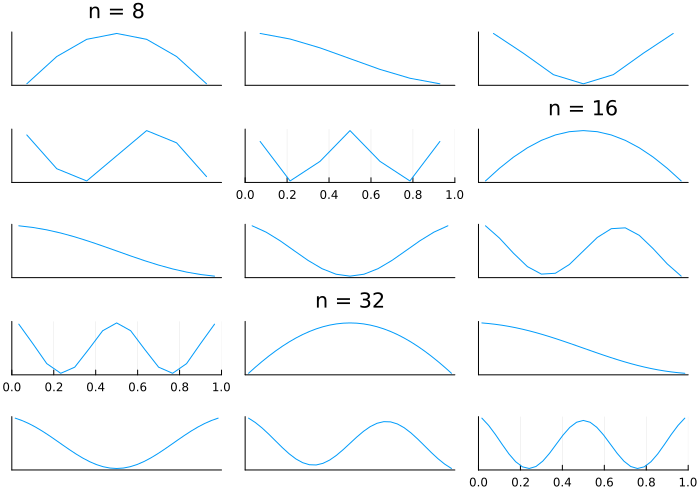

In [5]:
let ns = [8, 16, 32], m = 5
    local plots_arr = []
    for (j, k) in enumerate(ns)
        local pts_k, w_k, v_k = get_eigenpairs(k)
        for i in 1:m
            local p = plot(pts_k, v_k[:, i]; xlims=(0, 1), legend=false, yticks=[])
            if i == 1
                title!(p, "n = $k")
            end
            if i < m
                plot!(p; xticks=[])
            end
            push!(plots_arr, p)
        end
    end
    plot(plots_arr...; layout=(5, 3), size=(700, 500))
end

With the eigendecomposition, we can sample the Gaussian random field as $\boldsymbol{b} = V_{:,1:m}\, \mathrm{diag}(\sqrt{w_{1:m}})\, \boldsymbol{y}$:

In [6]:
function kl_evaluate(w, v; y=nothing)
    if isnothing(y)
        y = randn(length(w) - 1)
    end
    m = length(y)
    return v[:, 1:m] * (sqrt.(w[1:m]) .* y)
end

kl_evaluate (generic function with 1 method)

Let's plot a few realizations of the Gaussian random field $b(x, \omega)$:

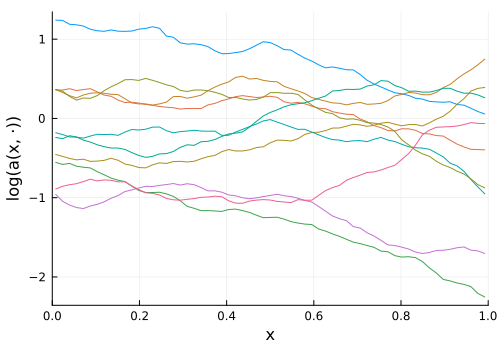

In [7]:
let n = 64
    local pts_gf, w_gf, v_gf = get_eigenpairs(n)
    local p = plot(; xlabel="x", ylabel="log(a(x, ⋅))", xlims=(0, 1), size=(500, 350))
    for _ in 1:10
        plot!(p, pts_gf, kl_evaluate(w_gf, v_gf); label=false)
    end
    p
end

### PDE Solver

Using a finite-difference discretization, the PDE reduces to a tridiagonal system solvable in $O(n)$ time via the Thomas algorithm. We assume $f(x) = 1$ and Dirichlet boundary conditions $u(0) = u(1) = 0$.

In [8]:
function thomas(a, b, c, d)
    n = length(b)
    b = copy(b)
    d = copy(d)
    x = zeros(n)
    for i in 2:n
        local w = a[i-1] / b[i-1]
        b[i] -= w * c[i-1]
        d[i] -= w * d[i-1]
    end
    x[n] = d[n] / b[n]
    for i in (n-1):-1:1
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    end
    return x
end

function pde_solve(a)
    n = length(a)
    rhs = fill(1.0 / n^2, n - 1)
    x = thomas(-a[2:n-1], a[1:n-1] .+ a[2:n], -a[2:n-1], rhs)
    return [0.0; x; 0.0]
end

pde_solve (generic function with 1 method)

Let's compute and plot several PDE solutions $u(x, \omega)$:

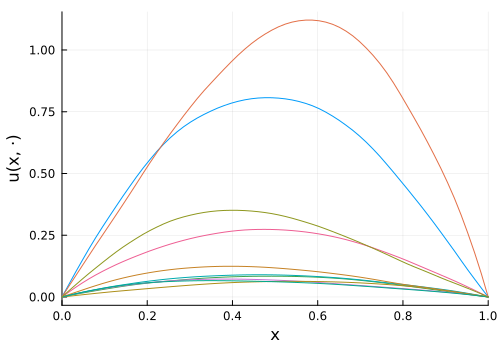

In [9]:
let n = 64
    local _, w_pde, v_pde = get_eigenpairs(n)
    local xgrid = range(0, 1, length=n)
    local p = plot(; xlabel="x", ylabel="u(x, ⋅)", xlims=(0, 1), size=(500, 350))
    for _ in 1:10
        local a = exp.(kl_evaluate(w_pde, v_pde))
        local u = pde_solve(a)
        plot!(p, xgrid, u; label=false)
    end
    p
end

### Coarse vs. Fine Grid Comparison

Multilevel methods rely on correlated coarse and fine grid solutions. Since we use the KL expansion, correlated samples are obtained by truncating the same random vector. Here we illustrate with fine grid $n_f = 16$ and coarse grid $n_c = 8$:

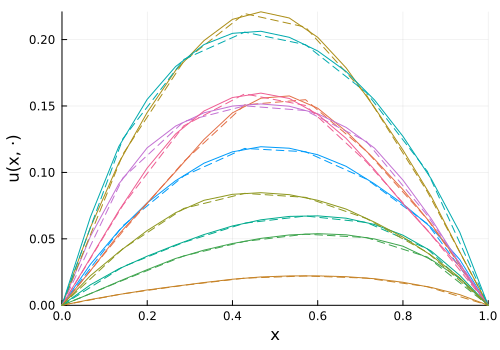

In [10]:
let nf = 16, nc = 8
    local _, wf, vf = get_eigenpairs(nf)
    local _, wc, vc = get_eigenpairs(nc)
    local xf = range(0, 1, length=nf)
    local xc = range(0, 1, length=nc)
    local p = plot(; xlabel="x", ylabel="u(x, ⋅)", xlims=(0, 1), ylims=(0, Inf), size=(500, 350))
    local colors = palette(:default)
    for k in 1:10
        local yf = randn(nf - 1)
        local af = exp.(kl_evaluate(wf, vf; y=yf))
        local uf = pde_solve(af)
        plot!(p, xf, uf; color=colors[mod1(k, length(colors))], label=false)
        local yc = yf[1:nc-1]
        local ac = exp.(kl_evaluate(wc, vc; y=yc))
        local uc = pde_solve(ac)
        plot!(p, xc, uc; color=colors[mod1(k, length(colors))], linestyle=:dash, label=false)
    end
    p
end

## 2. Single-Level Methods

We compute $\mathbb{E}[Q]$ where $Q = u(1/2, \cdot)$ is the PDE solution at the midpoint. We wrap the PDE evaluator in a `CustomFun` integrand and apply `CubMCCLT` (Monte Carlo) and `CubQMCLatticeG` (quasi-Monte Carlo with replicated lattice rules).

In [11]:
function make_elliptic_pde(dd; smoothness=1, lengthscale=1)
    dim = dd.dimension
    n_grid = dim + 1
    _, w, v = get_eigenpairs(n_grid; smoothness, lengthscale)
    tm = Gaussian(dd)
    g = x -> begin
        nrows = size(x, 1)
        out = zeros(nrows)
        for i in 1:nrows
            local a = exp.(kl_evaluate(w, v; y=x[i, :]))
            local u = pde_solve(a)
            out[i] = u[div(length(u), 2) + 1]
        end
        out
    end
    CustomFun(tm, g)
end

function test_method(dd, sc_type; abs_tol=5e-3, kwargs...)
    f = make_elliptic_pde(dd)
    sc = sc_type(f; abs_tol=abs_tol, kwargs...)
    local result
    t = @elapsed begin
        result = integrate(sc)
    end
    println(result)
    @printf("
Computed solution %.3f in %.2f s
", result.solution, t)
    return result
end

test_method (generic function with 1 method)

### Monte Carlo

The MC estimator is the sample average $\mathcal{Q}_N^{\mathrm{MC}} = \frac{1}{N}\sum_{n=0}^{N-1} Q^{(n)}$. We increase $N$ until the error criterion is satisfied. The solution should be $\approx 0.189$.

In [12]:
# MC with 32 stochastic dimensions
test_method(IIDStdUniform(32), CubMCCLT)

QMCResult(solution=1.883137e-01, error_bound=4.67e-03)

Computed solution 0.188 in 0.31 s


QMCResult(solution=1.883137e-01, error_bound=4.67e-03)

### Quasi-Monte Carlo

The QMC estimator uses low-discrepancy lattice points instead of random points. We run $K = 8$ independent replications to estimate the error:

In [13]:
# QMC with replicated lattice (32 dimensions, 8 replications)
test_method(Lattice(32; replications=8), CubQMCLatticeG; n_init=32)

QMCResult(solution=1.899168e-01, error_bound=4.10e-03)

Computed solution 0.190 in 0.15 s


QMCResult(solution=1.899168e-01, error_bound=4.10e-03)

## 3. Multilevel Methods (Coming Soon)

The Python version of this demo also applies multilevel Monte Carlo (`CubMLMC`) and multilevel quasi-Monte Carlo (`CubMLQMCCont`) methods, which exploit correlated coarse/fine grid solutions (illustrated in Section 1) to achieve faster convergence. These multilevel stopping criteria are not yet implemented in QMCJu. See the [Python demo](https://github.com/QMCSoftware/QMCSoftware/blob/develop/demos/elliptic-pde.ipynb) for the full multilevel analysis.